# YOLOv8 From Scratch — COCO Detection (Full Dataset Edition)
Fully annotated reimplementation of YOLOv8 (nano) trained on the **complete COCO dataset**
(~118 k train images / 5 k val images). No random subsetting — every annotated image is used.

In [ ]:
# =============================================================================
# Cell 1 – Imports, Device Setup & Adaptive Hyperparameters
# Full COCO edition: uses ALL annotated train2017 (~118 k) and val2017 (~5 k) images
# =============================================================================

import os, sys, json, time, math, random, warnings, itertools
from copy import deepcopy
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import MultiStepLR
from PIL import Image

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
# Prefer CUDA GPU; fall back to CPU automatically so the notebook runs anywhere.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

# ── AMP (Automatic Mixed Precision) ─────────────────────────────────────────
# AMP uses float16 on CUDA to speed up training and halve memory usage.
# On CPU there is no benefit, so we disable it.
use_amp = torch.cuda.is_available()
# GradScaler prevents float16 underflow during backprop.
scaler = torch.amp.GradScaler(device='cuda', enabled=use_amp) if use_amp else None

# ── Hardware-adaptive hyperparameters ────────────────────────────────────────
# CPU training is ~50-100x slower than GPU.  We shrink the workload so the
# notebook still runs end-to-end and every cell is exercised.
if torch.cuda.is_available():
    BATCH_SIZE      = 32     # images per gradient step; increase if VRAM allows
    EVAL_BATCH_SIZE = 32
    NUM_EPOCHS      = 65
    TRAIN_SUBSET    = 24000   # None = use ALL annotated train2017 images (~118 k)
    VAL_SUBSET      = 5000   # None = use ALL annotated val2017 images (~5 k)
    print("\nGPU detected – full-scale training.")
else:
    BATCH_SIZE      = 4
    EVAL_BATCH_SIZE = 4
    NUM_EPOCHS      = 5
    TRAIN_SUBSET    = 5000
    VAL_SUBSET      = 500
    print("\nCPU only – reduced-scale training for reasonable runtime.")

# ── COCO 80-class names (index 0 = background, not predicted) ────────────────
COCO_CLASSES = [
    '__background__',
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat',
    'dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack',
    'umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
    'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple',
    'sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair',
    'couch','potted plant','bed','dining table','toilet','tv','laptop','mouse',
    'remote','keyboard','cell phone','microwave','oven','toaster','sink',
    'refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]
NUM_CLASSES = len(COCO_CLASSES)   # 81 (80 fg + 1 bg)


Device : cuda
GPU    : NVIDIA GeForce RTX 5070
VRAM   : 12.8 GB
PyTorch: 2.8.0+cu128

GPU detected – full-scale training.


g:\AI Capstone Project\Code\YOLO\.capstone\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# =============================================================================
# Cell 2 – COCO Dataset Paths
# =============================================================================
# Expected directory layout under ./images/:
#   images/
#     train2017/          ← training JPEGs
#     val2017/            ← validation JPEGs
#     annotations/
#       instances_train2017.json
#       instances_val2017.json

COCO_DIR       = "./images"
TRAIN_IMG_DIR  = os.path.join(COCO_DIR, "train2017")
VAL_IMG_DIR    = os.path.join(COCO_DIR, "val2017")
TRAIN_ANN_FILE = os.path.join(COCO_DIR, "annotations", "instances_train2017.json")
VAL_ANN_FILE   = os.path.join(COCO_DIR, "annotations", "instances_val2017.json")

# Quick sanity-check: load the full annotation files and print counts.
with open(TRAIN_ANN_FILE) as f:
    train_ann = json.load(f)
print(f"Train images      : {len(train_ann['images']):,}")
print(f"Train annotations : {len(train_ann['annotations']):,}")
print(f"Categories        : {len(train_ann['categories'])}")


Train images      : 118,287
Train annotations : 860,001
Categories        : 80


Loading train annotations…
  Images with annotations: 117,266 / 118,287
  Sampled 24,000 images.
  Annotations kept: 175,389

Loading val annotations…
  Images with annotations: 4,952 / 5,000
  Sampled 4,952 images.
  Annotations kept: 36,781

[OK] Annotations saved to ./images\annotations_full


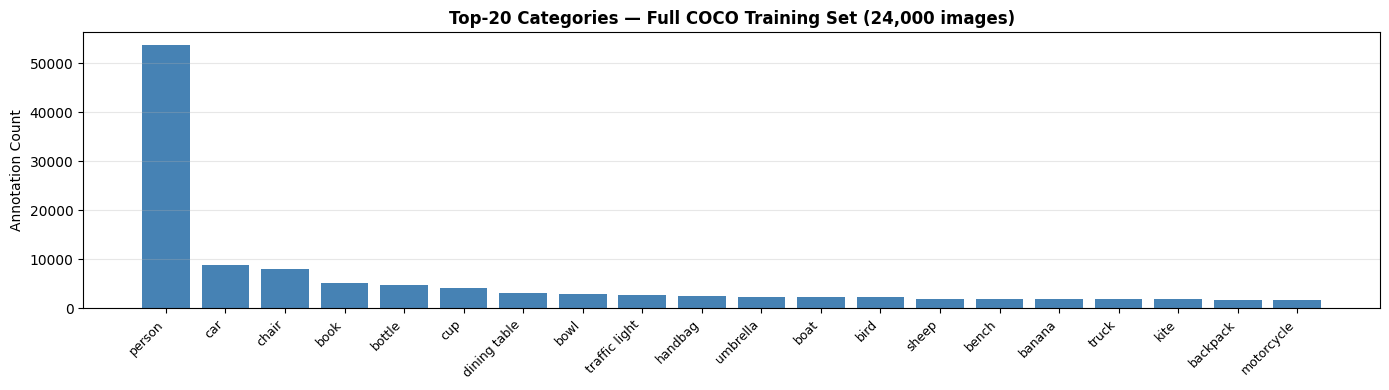

In [ ]:
# =============================================================================
# Cell 3 – Prepare Full COCO Annotations (No Subsetting)
# =============================================================================
# When TRAIN_SUBSET is None we use the complete COCO train2017 and val2017.
# We still filter to images that have at least one annotation (same as before).
# A lightweight per-category bar chart visualises the label distribution.

def load_full_or_subset(annotation_file, num_images, seed=42):
    """
    Load a COCO annotation file.
    If num_images is None, return the full set (filtered to annotated images).
    Otherwise sample num_images images reproducibly.
    """
    with open(annotation_file) as f:
        full = json.load(f)

    ids_with_ann = {a["image_id"] for a in full["annotations"]}
    imgs = [im for im in full["images"] if im["id"] in ids_with_ann]
    print(f"  Images with annotations: {len(imgs):,} / {len(full['images']):,}")

    if num_images is None:
        sel = imgs
        print(f"  Using ALL {len(sel):,} annotated images.")
    else:
        rng = random.Random(seed)
        sel = rng.sample(imgs, min(num_images, len(imgs)))
        print(f"  Sampled {len(sel):,} images.")

    sel_ids = {im["id"] for im in sel}
    sub = {k: v for k, v in full.items() if k not in ("images", "annotations")}
    sub["images"]      = sel
    sub["annotations"] = [a for a in full["annotations"] if a["image_id"] in sel_ids]
    sub["categories"]  = full["categories"]
    print(f"  Annotations kept: {len(sub['annotations']):,}")
    return sub

print("Loading train annotations…")
train_subset_ann = load_full_or_subset(TRAIN_ANN_FILE, TRAIN_SUBSET, seed=42)
print("\nLoading val annotations…")
val_subset_ann   = load_full_or_subset(VAL_ANN_FILE,   VAL_SUBSET,   seed=123)

SUBSET_DIR       = os.path.join(COCO_DIR, "annotations_full")
os.makedirs(SUBSET_DIR, exist_ok=True)
TRAIN_SUBSET_ANN = os.path.join(SUBSET_DIR, "train_full.json")
VAL_SUBSET_ANN   = os.path.join(SUBSET_DIR, "val_full.json")
with open(TRAIN_SUBSET_ANN, "w") as f: json.dump(train_subset_ann, f)
with open(VAL_SUBSET_ANN,   "w") as f: json.dump(val_subset_ann,   f)
print(f"\n[OK] Annotations saved to {SUBSET_DIR}")

# ── Category distribution bar chart ──────────────────────────────────────────
cat_id2name = {c["id"]: c["name"] for c in train_subset_ann["categories"]}
counts = Counter(a["category_id"] for a in train_subset_ann["annotations"])
top20  = counts.most_common(20)
names, vals = zip(*[(cat_id2name[k], v) for k, v in top20])

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(20), vals, color="steelblue")
ax.set_xticks(range(20))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
ax.set_title(f"Top-20 Categories — Full COCO Training Set ({len(train_subset_ann['images']):,} images)",
             fontweight="bold")
ax.set_ylabel("Annotation Count")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


Train: 24,000   Val: 4,952


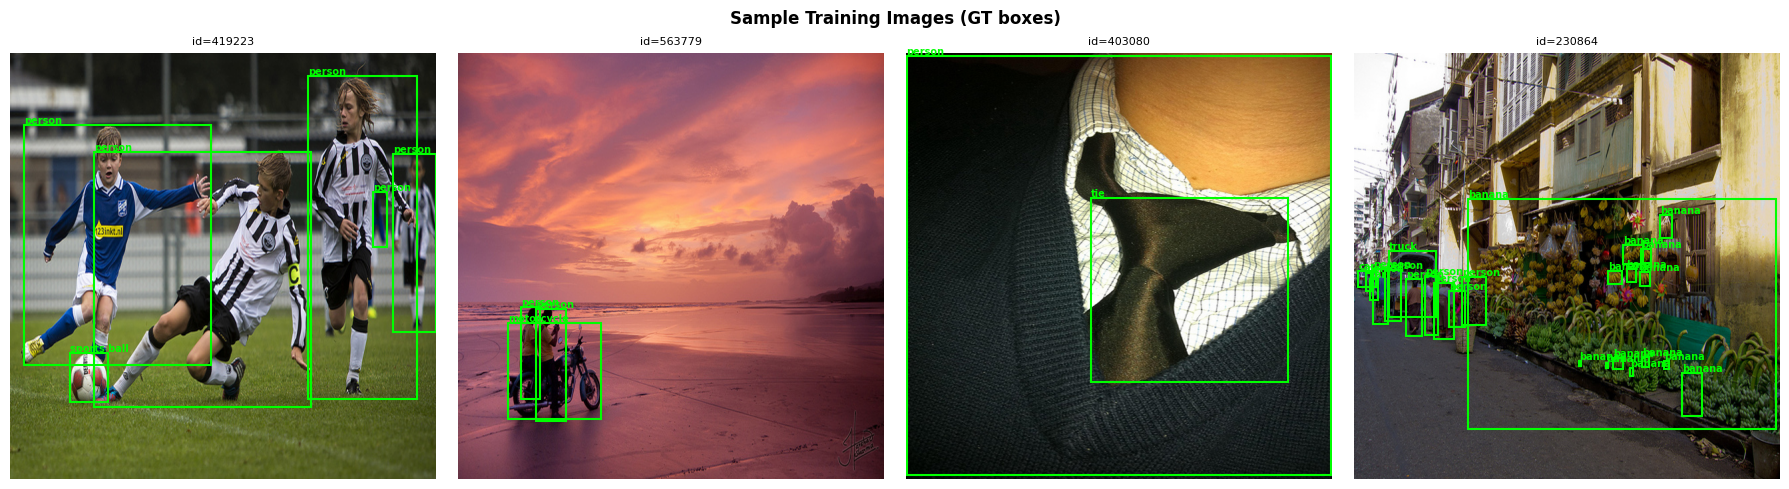

In [ ]:
# =============================================================================
# Cell 4 – COCO Detection Dataset
# =============================================================================
# Wraps COCO annotations into a PyTorch Dataset.
# Each sample is:
#   img_tensor  : FloatTensor (3, IMG_SIZE, IMG_SIZE) – ImageNet-normalised
#   target_dict : {boxes (N,4) xyxy, labels (N,) 1-indexed, image_id, orig_size}

class COCODetectionDataset(data.Dataset):
    # ImageNet mean/std used to normalise pixel values to approximately [-2, 2].
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, ann_dict, img_folder, img_size=640, augment=False):
        self.img_folder = img_folder
        self.img_size   = img_size
        self.augment    = augment   # enable simple horizontal-flip augmentation

        # Build image-id → metadata lookup.
        self.images  = {im["id"]: im for im in ann_dict["images"]}
        self.img_ids = list(self.images.keys())

        # Group annotations by image id for O(1) lookup in __getitem__.
        self.ann_by_img = {}
        for a in ann_dict["annotations"]:
            self.ann_by_img.setdefault(a["image_id"], []).append(a)

        # Map COCO category ids (non-contiguous, e.g. 1,2,3,…,90) to
        # contiguous 1-indexed labels (1,2,…,80) so the model's class dim
        # equals exactly NUM_CLASSES-1.
        sorted_cats    = sorted(ann_dict["categories"], key=lambda c: c["id"])
        self.cat2label = {c["id"]: i+1 for i, c in enumerate(sorted_cats)}

        # Normalisation transform applied after converting PIL → tensor.
        self.normalize = T.Normalize(self.MEAN, self.STD)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        info   = self.images[img_id]

        # Load image and resize to square (squashes aspect ratio but keeps
        # the pipeline simple; letterboxing would be more accurate).
        pil  = Image.open(os.path.join(self.img_folder, info["file_name"])).convert("RGB")
        ow, oh = pil.size          # original width, height (used for scale factors)
        pil    = pil.resize((self.img_size, self.img_size))
        sx, sy = self.img_size / ow, self.img_size / oh   # scale factors

        # Random horizontal flip (training augmentation only).
        flip = self.augment and random.random() > 0.5
        if flip:
            pil = TF.hflip(pil)

        # PIL → tensor (HWC uint8 → CHW float32 in [0,1]) → ImageNet normalise.
        img = self.normalize(TF.to_tensor(pil))

        # Build box and label tensors, applying the same scale/flip as the image.
        boxes, labels = [], []
        for a in self.ann_by_img.get(img_id, []):
            x, y, w, h = a["bbox"]            # COCO stores xywh
            x1, y1 = x * sx, y * sy
            x2, y2 = (x + w) * sx, (y + h) * sy

            # Mirror x-coordinates when the image is flipped.
            if flip:
                x1, x2 = self.img_size - x2, self.img_size - x1

            # Clamp to image bounds and skip degenerate boxes.
            x1 = max(0, min(x1, self.img_size))
            y1 = max(0, min(y1, self.img_size))
            x2 = max(0, min(x2, self.img_size))
            y2 = max(0, min(y2, self.img_size))
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(self.cat2label[a["category_id"]])

        # Return empty tensors if the image has no valid annotations.
        boxes  = torch.tensor(boxes,  dtype=torch.float32) if boxes  else torch.zeros((0, 4))
        labels = torch.tensor(labels, dtype=torch.long)    if labels else torch.zeros((0,), dtype=torch.long)

        return img, {"boxes": boxes, "labels": labels,
                     "image_id": img_id, "orig_size": (oh, ow)}


def collate_fn(batch):
    """Stack images into a batch tensor; keep targets as a list (variable N)."""
    imgs, tgts = zip(*batch)
    return torch.stack(imgs), list(tgts)


IMG_SIZE      = 640
train_dataset = COCODetectionDataset(train_subset_ann, TRAIN_IMG_DIR, IMG_SIZE, augment=True)
val_dataset   = COCODetectionDataset(val_subset_ann,   VAL_IMG_DIR,   IMG_SIZE, augment=False)
print(f"Train: {len(train_dataset):,}   Val: {len(val_dataset):,}")

# ── Sanity visualisation: 4 random training images with GT boxes ──────────────
inv_norm = T.Normalize(
    mean=[-m/s for m, s in zip(COCODetectionDataset.MEAN, COCODetectionDataset.STD)],
    std=[1/s for s in COCODetectionDataset.STD]
)
label2cat = {v: k for k, v in train_dataset.cat2label.items()}
catname   = {c["id"]: c["name"] for c in train_subset_ann["categories"]}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax in axes:
    img_t, tgt = train_dataset[random.randint(0, len(train_dataset)-1)]
    vis = inv_norm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(vis)
    for box, lbl in zip(tgt["boxes"], tgt["labels"]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, lw=1.5, edgecolor="lime", fc="none")
        ax.add_patch(rect)
        cid  = label2cat.get(lbl.item(), 0)
        name = catname.get(cid, str(lbl.item()))
        ax.text(x1, y1-2, name, color="lime", fontsize=7, fontweight="bold")
    ax.axis("off"); ax.set_title(f"id={tgt['image_id']}", fontsize=8)
plt.suptitle("Sample Training Images (GT boxes)", fontweight="bold")
plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# Cell 5 – CSPDarknet Backbone (built from scratch)
# =============================================================================
# Produces three feature maps at different spatial scales:
#   P3 (stride  8) – fine-grained, good for small objects
#   P4 (stride 16) – medium scale
#   P5 (stride 32) – coarse, rich semantic features
#
# Key building blocks:
#   ConvBnSilu  – Conv2d → BN → SiLU  (fused activation, better than ReLU)
#   Bottleneck  – two 3×3 ConvBnSilu blocks with optional residual shortcut
#   C2f         – Cross-Stage-Partial fusion (YOLOv8's key innovation over C3)
#   SPPF        – Spatial Pyramid Pooling Fast (multi-scale context at P5)
# =============================================================================

class ConvBnSilu(nn.Module):
    """Conv2d → BatchNorm2d → SiLU activation.  The universal building block."""
    def __init__(self, in_ch, out_ch, k=1, s=1, p=None, g=1, d=1):
        super().__init__()
        # Auto-pad to preserve spatial size when stride=1.
        if p is None: p = (k-1)//2 * d
        self.conv = nn.Conv2d(in_ch, out_ch, k, s, p, groups=g, dilation=d, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch, momentum=0.03, eps=1e-3)
        self.act  = nn.SiLU(inplace=True)   # SiLU(x) = x * sigmoid(x)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class Bottleneck(nn.Module):
    """
    Standard YOLOv8 bottleneck: 3×3 → 3×3 with optional identity shortcut.
    The expansion ratio `e` controls the intermediate channel width.
    Shortcut is only added when in/out channels match (c1==c2).
    """
    def __init__(self, c1, c2, shortcut=True, g=1, e=0.5):
        super().__init__()
        c_ = int(c2 * e)           # hidden channels
        self.cv1 = ConvBnSilu(c1, c_, 3)
        self.cv2 = ConvBnSilu(c_, c2, 3, g=g)
        self.add = shortcut and (c1 == c2)   # only add skip if channels match

    def forward(self, x):
        return x + self.cv2(self.cv1(x)) if self.add else self.cv2(self.cv1(x))


class C2f(nn.Module):
    """
    Cross-Stage-Partial Feature Fusion (2-fork split).
    YOLOv8's key innovation: replaces C3 from YOLOv5/v7.

    Forward pass:
      1. cv1 projects input to 2*c channels, then splits into two halves.
      2. One half passes through n Bottleneck blocks sequentially.
      3. All intermediate tensors (both halves + each bottleneck output)
         are concatenated and projected back to c2 channels via cv2.
    This gives a dense gradient flow similar to DenseNet.
    """
    def __init__(self, c1, c2, n=1, shortcut=False, g=1, e=0.5):
        super().__init__()
        self.c   = int(c2 * e)                     # channels per branch
        self.cv1 = ConvBnSilu(c1, 2 * self.c)      # split projection
        self.cv2 = ConvBnSilu((2 + n) * self.c, c2) # merge projection
        self.m   = nn.ModuleList(
            Bottleneck(self.c, self.c, shortcut, g, e=1.0) for _ in range(n)
        )

    def forward(self, x):
        # Split into two equal halves along channel dim.
        y = list(self.cv1(x).chunk(2, 1))
        # Append output of each bottleneck block.
        y.extend(m(y[-1]) for m in self.m)
        # Concatenate all and project to output channels.
        return self.cv2(torch.cat(y, 1))


class SPPF(nn.Module):
    """
    Spatial Pyramid Pooling Fast.
    Three sequential max-pools with the same kernel, then concat with input.
    Equivalent to SPP{5,9,13} but uses only one max-pool layer definition.
    Applied at the deepest backbone stage to capture multi-scale context.
    """
    def __init__(self, c1, c2, k=5):
        super().__init__()
        c_ = c1 // 2
        self.cv1 = ConvBnSilu(c1, c_)      # channel reduction before pooling
        self.cv2 = ConvBnSilu(c_ * 4, c2)  # merge 4 tensors (input + 3 pools)
        self.m   = nn.MaxPool2d(k, stride=1, padding=k // 2)

    def forward(self, x):
        x  = self.cv1(x)
        # Three nested max-pools capture contexts at scales 5, 9, 13.
        y1 = self.m(x)
        y2 = self.m(y1)
        y3 = self.m(y2)
        return self.cv2(torch.cat([x, y1, y2, y3], 1))


class CSPDarknet(nn.Module):
    """
    YOLOv8 CSPDarknet backbone.

    `depth_multiple` scales how many Bottleneck repeats each C2f block has.
    `width_multiple` scales all channel widths.
    Nano defaults: depth=0.33, width=0.25  (~1.8 M params)
    """
    def __init__(self, depth_multiple=0.33, width_multiple=0.25):
        super().__init__()
        # Helper: round channel count and depth to valid integers.
        def ch(c): return max(round(c * width_multiple), 1)
        def nd(n): return max(round(n * depth_multiple), 1)

        # Stem: halves resolution from 640 → 320.
        self.stem   = ConvBnSilu(3, ch(64), 3, 2)

        # Stage 1 (320 → 160): first C2f block.
        self.stage1 = nn.Sequential(
            ConvBnSilu(ch(64),  ch(128), 3, 2),
            C2f(ch(128), ch(128), nd(3), shortcut=True)
        )
        # Stage 2 (160 → 80): produces P3.
        self.stage2 = nn.Sequential(
            ConvBnSilu(ch(128), ch(256), 3, 2),
            C2f(ch(256), ch(256), nd(6), shortcut=True)
        )
        # Stage 3 (80 → 40): produces P4.
        self.stage3 = nn.Sequential(
            ConvBnSilu(ch(256), ch(512), 3, 2),
            C2f(ch(512), ch(512), nd(6), shortcut=True)
        )
        # Stage 4 (40 → 20): produces P5 with SPPF for large receptive field.
        self.stage4 = nn.Sequential(
            ConvBnSilu(ch(512), ch(1024), 3, 2),
            C2f(ch(1024), ch(1024), nd(3), shortcut=True),
            SPPF(ch(1024), ch(1024))
        )
        self.out_channels = [ch(256), ch(512), ch(1024)]

    def forward(self, x):
        x  = self.stem(x)
        x  = self.stage1(x)
        p3 = self.stage2(x)   # stride  8 feature map
        p4 = self.stage3(p3)  # stride 16 feature map
        p5 = self.stage4(p4)  # stride 32 feature map
        return p3, p4, p5


# ── Shape check ──────────────────────────────────────────────────────────────
_b = CSPDarknet()
_p3, _p4, _p5 = _b(torch.zeros(1, 3, 640, 640))
print("Backbone output shapes (nano, batch=1, input=640×640):")
print(f"  P3 stride  8 : {tuple(_p3.shape)}")
print(f"  P4 stride 16 : {tuple(_p4.shape)}")
print(f"  P5 stride 32 : {tuple(_p5.shape)}")
del _b, _p3, _p4, _p5


Backbone output shapes (nano, batch=1, input=640×640):
  P3 stride  8 : (1, 64, 80, 80)
  P4 stride 16 : (1, 128, 40, 40)
  P5 stride 32 : (1, 256, 20, 20)


In [ ]:
# =============================================================================
# Cell 6 – PANet Neck (Bidirectional Feature Pyramid)
# =============================================================================
# The neck fuses multi-scale backbone features before the detection heads.
#
# Two passes:
#   Top-down (FPN): P5 → P4 → P3   upsample + concat + C2f
#     Brings high-level semantics down to small-object feature maps.
#   Bottom-up (PAN): P3 → P4 → P5  downsample + concat + C2f
#     Propagates fine-grained location information back up.
#
# Outputs N3/N4/N5 each with `out_channels` channels at strides 8/16/32.
# =============================================================================

class PANetNeck(nn.Module):
    def __init__(self, in_channels, out_channels=256, depth_multiple=0.33):
        super().__init__()
        c3, c4, c5 = in_channels
        o = out_channels
        def nd(n): return max(round(n * depth_multiple), 1)

        # ── Top-down FPN path ─────────────────────────────────────────────────
        self.reduce_p5 = ConvBnSilu(c5, o)      # compress P5 channels
        # After upsampling P5 and concatenating with P4 → run C2f.
        self.c2f_p4    = C2f(o + c4, o, nd(3))
        self.reduce_p4 = ConvBnSilu(o, o)       # compress merged P4 channels
        # After upsampling reduced-P4 and concatenating with P3 → run C2f → N3.
        self.c2f_p3    = C2f(o + c3, o, nd(3))

        # ── Bottom-up PAN path ────────────────────────────────────────────────
        # Stride-2 conv downsamples N3 before merging with top-down P4.
        self.down1  = ConvBnSilu(o, o, 3, 2)
        self.c2f_n4 = C2f(o + o, o, nd(3))     # → N4
        self.down2  = ConvBnSilu(o, o, 3, 2)
        self.c2f_n5 = C2f(o + o, o, nd(3))     # → N5

        self.out_channels = [o, o, o]

    def forward(self, feats):
        p3, p4, p5 = feats

        # Top-down: enrich small-scale maps with deep semantics.
        p5r  = self.reduce_p5(p5)
        # nearest-neighbour upsample doubles H,W cheaply.
        p4td = self.c2f_p4(torch.cat([F.interpolate(p5r, scale_factor=2, mode="nearest"), p4], 1))
        p4r  = self.reduce_p4(p4td)
        n3   = self.c2f_p3(torch.cat([F.interpolate(p4r, scale_factor=2, mode="nearest"), p3], 1))

        # Bottom-up: restore spatial accuracy at larger scales.
        n4 = self.c2f_n4(torch.cat([self.down1(n3), p4td], 1))
        n5 = self.c2f_n5(torch.cat([self.down2(n4), p5r],  1))

        return n3, n4, n5   # strides 8, 16, 32


# ── Shape check ──────────────────────────────────────────────────────────────
_b = CSPDarknet(); _n = PANetNeck(_b.out_channels, 256)
_n3, _n4, _n5 = _n(_b(torch.zeros(1, 3, 640, 640)))
print("PANet Neck output shapes:")
print(f"  N3 stride  8 : {tuple(_n3.shape)}")
print(f"  N4 stride 16 : {tuple(_n4.shape)}")
print(f"  N5 stride 32 : {tuple(_n5.shape)}")
del _b, _n, _n3, _n4, _n5


PANet Neck output shapes:
  N3 stride  8 : (1, 256, 80, 80)
  N4 stride 16 : (1, 256, 40, 40)
  N5 stride 32 : (1, 256, 20, 20)


In [ ]:
# =============================================================================
# Cell 7 – Decoupled Anchor-Free Detection Heads
# =============================================================================
# YOLOv8 is fully anchor-free: every feature-map cell predicts its box
# directly without pre-defined anchor boxes.
#
# DFL (Distribution Focal Loss) layer
#   Instead of regressing one distance value per side, the model predicts
#   a probability distribution over `reg_max` discrete bins.
#   The expected value (soft-argmax) gives the final distance.
#
# make_anchors
#   Generates a grid of (cx, cy) anchor points, one per feature-map cell.
#
# DecoupledHead
#   Shared base: two separate conv branches for regression (cv2) and
#   classification (cv3) at each of the 3 FPN scales.
#   Decoupling avoids task interference seen in coupled heads.
#
# Task-specific subclasses add extra outputs on top of the base head:
#   DetectionHead     – boxes + class logits
#   SegmentationHead  – + mask coefficients + prototype masks
#   PoseHead          – + keypoint coordinates
#   OBBHead           – + rotation angle
#   ClassificationHead– global-pool → linear (image-level classification)
# =============================================================================

class DFL(nn.Module):
    """
    Distribution Focal Loss integral layer.
    Input : (B, 4*reg_max, H, W)  or  (B, 4*reg_max, N) after flattening.
    Output: (B, 4, H, W)          or  (B, 4, N)
    Each of the 4 distance predictions becomes a soft-argmax over reg_max bins.
    """
    def __init__(self, reg_max=16):
        super().__init__()
        self.reg_max = reg_max
        # Fixed integer bins [0, 1, …, reg_max-1]; not learned.
        self.register_buffer("proj", torch.arange(reg_max, dtype=torch.float))

    def forward(self, x):
        if x.ndim == 4:   # spatial feature-map path
            B, _, H, W = x.shape
            x = F.softmax(x.view(B, 4, self.reg_max, H, W), dim=2)
            return (x * self.proj.view(1, 1, -1, 1, 1)).sum(2)
        else:             # flattened anchor path (used in _decode)
            B, _, N = x.shape
            x = F.softmax(x.view(B, 4, self.reg_max, N), dim=2)
            return (x * self.proj.view(1, 1, -1, 1)).sum(2)


def make_anchors(feats, strides, offset=0.5):
    """
    Build anchor-point grids for each FPN level.
    Each cell centre is at (col+0.5, row+0.5) in feature-map coordinates.
    Returns:
      pts  : (total_anchors, 2) – (cx, cy) in feature-map space
      strd : (total_anchors, 1) – stride value for each anchor
    """
    pts, strd = [], []
    for feat, s in zip(feats, strides):
        _, _, h, w = feat.shape
        gx = torch.arange(w, dtype=torch.float32, device=feat.device) + offset
        gy = torch.arange(h, dtype=torch.float32, device=feat.device) + offset
        gy, gx = torch.meshgrid(gy, gx, indexing="ij")
        pts.append(torch.stack([gx, gy], -1).view(-1, 2))
        strd.append(torch.full((h*w, 1), float(s), device=feat.device))
    return torch.cat(pts), torch.cat(strd)


def dist2bbox(dist, anchors):
    """
    Convert (left, top, right, bottom) distances from anchor centre → xyxy boxes.
    dist    : (B, N, 4) distances in input-pixel space (already multiplied by stride)
    anchors : (N, 2) anchor centres in input-pixel space
    """
    return torch.cat([anchors - dist[..., :2], anchors + dist[..., 2:]], -1)


class DecoupledHead(nn.Module):
    """
    Shared base for all YOLOv8 task heads.
    Maintains separate regression (cv2) and classification (cv3) branches
    for each of the 3 FPN scales.
    """
    def __init__(self, nc, in_channels, reg_max=16, num_convs=2):
        super().__init__()
        self.nc      = nc        # number of foreground classes
        self.reg_max = reg_max   # DFL bin count (16 by default)
        self.strides = [8, 16, 32]
        self.nl      = len(in_channels)   # number of FPN levels (3)

        # Channel widths for regression and classification branches.
        c2 = max(in_channels[0], min(nc, 100))
        c3 = max(in_channels[0], nc)

        # Regression branch: predicts 4 * reg_max values per anchor.
        self.cv2 = nn.ModuleList(
            nn.Sequential(
                *[ConvBnSilu(in_channels[i] if j == 0 else c2, c2, 3) for j in range(num_convs)],
                nn.Conv2d(c2, 4 * reg_max, 1)
            )
            for i in range(self.nl)
        )
        # Classification branch: predicts nc logits per anchor.
        self.cv3 = nn.ModuleList(
            nn.Sequential(
                *[ConvBnSilu(in_channels[i] if j == 0 else c3, c3, 3) for j in range(num_convs)],
                nn.Conv2d(c3, nc, 1)
            )
            for i in range(self.nl)
        )
        self.dfl = DFL(reg_max)

    def _decode(self, feats):
        """
        Run regression and classification branches, then decode boxes.
        Returns (boxes_xyxy, class_logits, anchor_pts, strides).
        """
        B = feats[0].shape[0]
        reg = [self.cv2[i](feats[i]) for i in range(self.nl)]
        cls = [self.cv3[i](feats[i]) for i in range(self.nl)]

        # Build anchor grids matching the current feature map sizes.
        anc, strd = make_anchors(feats, self.strides)

        # Flatten spatial dims and permute to (B, N, C).
        reg_f = torch.cat([r.view(B, 4*self.reg_max, -1).permute(0, 2, 1) for r in reg], 1)
        cls_f = torch.cat([c.view(B, self.nc,        -1).permute(0, 2, 1) for c in cls], 1)

        # DFL → distances → xyxy boxes in input-pixel space.
        dist  = self.dfl(reg_f.permute(0, 2, 1).view(B, 4*self.reg_max, -1)).permute(0, 2, 1)
        boxes = dist2bbox(dist * strd, anc * strd)
        return boxes, cls_f, anc, strd

    def forward(self, feats): raise NotImplementedError


class DetectionHead(DecoupledHead):
    """Standard detection: returns (boxes_xyxy, class_logits)."""
    def forward(self, feats):
        boxes, cls, _, _ = self._decode(feats)
        return boxes, cls


class SegmentationHead(DecoupledHead):
    """
    Instance segmentation: additionally predicts per-anchor mask coefficients
    and a set of prototype masks at the N3 scale.
    Final binary mask for anchor i = sigmoid(coeff_i @ protos).
    """
    def __init__(self, nc, in_ch, reg_max=16, nm=32):
        super().__init__(nc, in_ch, reg_max)
        self.nm = nm   # number of prototype masks
        c4 = max(in_ch[0] // 4, nm)
        # Coefficient branch: one nm-dim vector per anchor.
        self.cv4 = nn.ModuleList(
            nn.Sequential(ConvBnSilu(in_ch[i], c4, 3), ConvBnSilu(c4, c4, 3),
                          nn.Conv2d(c4, nm, 1))
            for i in range(self.nl)
        )
        # Prototype generator: upsamples N3 by 2× for higher-res masks.
        self.proto = nn.Sequential(
            ConvBnSilu(in_ch[0], nm, 3),
            nn.Upsample(scale_factor=2, mode="nearest"),
            ConvBnSilu(nm, nm, 3),
            nn.Conv2d(nm, nm, 1)
        )

    def forward(self, feats):
        boxes, cls, _, _ = self._decode(feats)
        B = feats[0].shape[0]
        coeff  = torch.cat([self.cv4[i](feats[i]).view(B, self.nm, -1).permute(0, 2, 1)
                            for i in range(self.nl)], 1)
        protos = self.proto(feats[0])
        return boxes, cls, coeff, protos


class PoseHead(DecoupledHead):
    """
    Pose estimation: predicts (x, y [, visibility]) per keypoint per anchor.
    kpt_shape = (nkpt, ndim): ndim=2 for xy, ndim=3 for xy+vis.
    """
    def __init__(self, nc, in_ch, kpt_shape=(17, 3), reg_max=16):
        super().__init__(nc, in_ch, reg_max)
        self.kpt_shape = kpt_shape
        nkpt = kpt_shape[0] * kpt_shape[1]
        c5 = max(in_ch[0] // 2, nkpt)
        self.cv5 = nn.ModuleList(
            nn.Sequential(ConvBnSilu(in_ch[i], c5, 3), ConvBnSilu(c5, c5, 3),
                          nn.Conv2d(c5, nkpt, 1))
            for i in range(self.nl)
        )
        self._nkpt = nkpt

    def forward(self, feats):
        boxes, cls, _, _ = self._decode(feats)
        B = feats[0].shape[0]
        kpts = torch.cat([self.cv5[i](feats[i]).view(B, self._nkpt, -1).permute(0, 2, 1)
                          for i in range(self.nl)], 1)
        return boxes, cls, kpts


class OBBHead(DecoupledHead):
    """
    Oriented Bounding Box: additionally predicts a rotation angle in [-π/4, π/4].
    Uses tanh to keep the prediction bounded.
    """
    def __init__(self, nc, in_ch, reg_max=16):
        super().__init__(nc, in_ch, reg_max)
        c6 = max(in_ch[0] // 4, 1)
        self.cv6 = nn.ModuleList(
            nn.Sequential(ConvBnSilu(in_ch[i], c6, 3), nn.Conv2d(c6, 1, 1))
            for i in range(self.nl)
        )

    def forward(self, feats):
        boxes, cls, _, _ = self._decode(feats)
        B = feats[0].shape[0]
        ang = torch.cat([self.cv6[i](feats[i]).view(B, 1, -1).permute(0, 2, 1)
                         for i in range(self.nl)], 1)
        return boxes, cls, (math.pi / 4) * torch.tanh(ang)


class ClassificationHead(nn.Module):
    """
    Image-level classification.
    Global average pool on the deepest neck feature → dropout → linear.
    """
    def __init__(self, in_ch, nc=1000):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(in_ch, nc)

    def forward(self, x):
        return self.fc(self.drop(self.pool(x).flatten(1)))


# ── Sanity checks for all head types ─────────────────────────────────────────
_b  = CSPDarknet(0.33, 0.25); _n = PANetNeck(_b.out_channels, 256)
_fs = _n(_b(torch.zeros(1, 3, 640, 640))); _ch = [256, 256, 256]
_det  = DetectionHead(80, _ch)
_seg  = SegmentationHead(80, _ch)
_pose = PoseHead(80, _ch, (17, 3))
_obb  = OBBHead(80, _ch)
_cls  = ClassificationHead(256, 80)
print("Head output shapes (batch=1):")
bx, sc               = _det(_fs);          print(f"  Detection  boxes:{tuple(bx.shape)}  scores:{tuple(sc.shape)}")
bx, sc, co, pr       = _seg(_fs);          print(f"  Segment    coeff:{tuple(co.shape)}  protos:{tuple(pr.shape)}")
bx, sc, kp           = _pose(_fs);         print(f"  Pose       kpts:{tuple(kp.shape)}")
bx, sc, ag           = _obb(_fs);          print(f"  OBB        angle:{tuple(ag.shape)}")
cl                   = _cls(_fs[2]);       print(f"  Classify   logits:{tuple(cl.shape)}")
del _b, _n, _fs, _det, _seg, _pose, _obb, _cls, bx, sc, co, pr, kp, ag, cl


Head output shapes (batch=1):
  Detection  boxes:(1, 8400, 4)  scores:(1, 8400, 80)
  Segment    coeff:(1, 8400, 32)  protos:(1, 32, 160, 160)
  Pose       kpts:(1, 8400, 51)
  OBB        angle:(1, 8400, 1)
  Classify   logits:(1, 80)


In [ ]:
# =============================================================================
# Cell 8 – YOLOv8 Unified Multi-Task Model
# =============================================================================
# YOLOv8 = CSPDarknet backbone + PANetNeck + one task head.
# The `scale` parameter controls width/depth multipliers.
# =============================================================================

class YOLOv8(nn.Module):
    # Predefined (depth_multiple, width_multiple) pairs for each scale.
    SCALES = {"n": (0.33, 0.25), "s": (0.33, 0.50),
              "m": (0.67, 0.75), "l": (1.00, 1.00), "x": (1.00, 1.25)}

    def __init__(self, task="detect", nc=80, scale="n", kpt_shape=(17, 3), nm=32):
        super().__init__()
        self.task = task
        self.nc   = nc
        dm, wm    = self.SCALES[scale]
        neck_ch   = max(round(256 * wm), 1)   # unified neck channel width

        self.backbone = CSPDarknet(dm, wm)
        self.neck     = PANetNeck(self.backbone.out_channels, neck_ch, dm)
        in_ch         = self.neck.out_channels   # [neck_ch, neck_ch, neck_ch]

        # Attach the appropriate head for the requested task.
        if   task == "detect":   self.head = DetectionHead(nc, in_ch)
        elif task == "segment":  self.head = SegmentationHead(nc, in_ch, nm=nm)
        elif task == "pose":     self.head = PoseHead(nc, in_ch, kpt_shape)
        elif task == "obb":      self.head = OBBHead(nc, in_ch)
        elif task == "classify": self.head = ClassificationHead(in_ch[-1], nc)
        else: raise ValueError(f"Unknown task '{task}'.")

        self._init_weights()

    def _init_weights(self):
        """Kaiming-normal for conv; ones/zeros for BN."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        feats = self.neck(self.backbone(x))
        # ClassificationHead only needs the deepest feature map.
        return self.head(feats[-1] if self.task == "classify" else feats)

    def param_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Print parameter counts for all scales to show the trade-off.
print(f"{'Scale':<8} {'Params':>12}")
print("-" * 22)
for sc in ["n", "s", "m", "l", "x"]:
    m = YOLOv8(task="detect", nc=80, scale=sc)
    print(f"  {sc}      {m.param_count():>12,}")
del m

# Instantiate the working model (nano scale, 80 foreground classes).
model = YOLOv8(task="detect", nc=NUM_CLASSES-1, scale="n").to(device)
print(f"\nWorking model: YOLOv8-nano  {model.param_count():,} parameters")
_o = model(torch.zeros(1, 3, 640, 640, device=device))
print(f"  boxes  shape : {tuple(_o[0].shape)}")
print(f"  scores shape : {tuple(_o[1].shape)}")
del _o


Scale          Params
----------------------
  n         2,163,072
  s         7,829,584
  m        23,142,240
  l        51,009,776
  x        79,652,032

Working model: YOLOv8-nano  2,163,072 parameters
  boxes  shape : (1, 8400, 4)
  scores shape : (1, 8400, 80)


In [ ]:
# =============================================================================
# Cell 9 – YOLOv8 Loss Function (built from scratch)
# =============================================================================

def bbox_ciou(b1, b2, eps=1e-7):
    """Complete IoU between two (N,4) xyxy tensor pairs. Returns (N,) tensor."""
    b1x1, b1y1, b1x2, b1y2 = b1.unbind(-1)
    b2x1, b2y1, b2x2, b2y2 = b2.unbind(-1)
    inter = ((torch.min(b1x2, b2x2) - torch.max(b1x1, b2x1)).clamp(0) *
             (torch.min(b1y2, b2y2) - torch.max(b1y1, b2y1)).clamp(0))
    w1, h1 = b1x2 - b1x1, b1y2 - b1y1
    w2, h2 = b2x2 - b2x1, b2y2 - b2y1
    union  = w1*h1 + w2*h2 - inter + eps
    iou    = inter / union
    cw  = torch.max(b1x2, b2x2) - torch.min(b1x1, b2x1)
    ch  = torch.max(b1y2, b2y2) - torch.min(b1y1, b2y1)
    c2  = cw**2 + ch**2 + eps
    rho2 = ((b2x1+b2x2 - b1x1-b1x2)**2 + (b2y1+b2y2 - b1y1-b1y2)**2) / 4
    v     = (4 / math.pi**2) * (torch.atan(w2/(h2+eps)) - torch.atan(w1/(h1+eps)))**2
    with torch.no_grad():
        alpha = v / (1 - iou + v + eps)
    return iou - (rho2 / c2 + v * alpha)


class TaskAlignedAssigner(nn.Module):
    """
    Assigns GT boxes to anchor points.
    Alignment score = sigmoid(p_cls)^alpha * CIoU^beta for anchors inside GT.
    Top-k per GT selected; conflicts resolved by highest score.
    """
    def __init__(self, topk=10, alpha=0.5, beta=6.0):
        super().__init__()
        self.topk  = topk
        self.alpha = alpha
        self.beta  = beta

    @torch.no_grad()
    def forward(self, pd_scores, pd_boxes, anc_pts_px, gt_labels, gt_boxes):
        """
        pd_scores   : (B, N, nc)  float32
        pd_boxes    : (B, N, 4)   float32  xyxy in INPUT-PIXEL space
        anc_pts_px  : (N, 2)      float32  anchor centres in INPUT-PIXEL space
        gt_labels   : (B, M)      long     0-indexed
        gt_boxes    : (B, M, 4)   float32  xyxy in INPUT-PIXEL space
        """
        B, N, nc = pd_scores.shape
        dev = pd_scores.device

        tgt_labels = torch.full((B, N),    -1,  dtype=torch.long,    device=dev)
        tgt_boxes  = torch.zeros(B, N, 4,        dtype=torch.float32, device=dev)
        fg_mask    = torch.zeros(B, N,           dtype=torch.bool,    device=dev)

        for b in range(B):
            gb = gt_boxes[b]; lb = gt_labels[b]
            valid = (gb[:, 2] > gb[:, 0]) & (gb[:, 3] > gb[:, 1])
            gb = gb[valid]; lb = lb[valid]; m = gb.shape[0]
            if m == 0:
                continue

            # in_b: anchor n is inside GT box j (pixel space on both sides -- correct)
            ax = anc_pts_px[:, 0:1]; ay = anc_pts_px[:, 1:2]   # (N,1)
            in_b = ((ax >= gb[:, 0]) & (ax <= gb[:, 2]) &
                    (ay >= gb[:, 1]) & (ay <= gb[:, 3]))          # (N, m)

            # IoU between predicted boxes and GT boxes
            b1e = pd_boxes[b].unsqueeze(1).expand(-1, m, -1).reshape(-1, 4)
            b2e = gb.unsqueeze(0).expand(N, -1, -1).reshape(-1, 4)
            iou = bbox_ciou(b1e, b2e).clamp(0).view(N, m)

            cls_sc = pd_scores[b].sigmoid()[:, lb.clamp(0, nc-1)]   # (N, m)
            align  = (cls_sc ** self.alpha) * (iou ** self.beta) * in_b.float()

            _, tk_idx = align.topk(min(self.topk, N), dim=0)
            tk_mask = torch.zeros_like(align, dtype=torch.bool).scatter_(0, tk_idx, 1)
            tk_mask &= in_b

            best_al, best_gt = (align * tk_mask.float()).max(dim=1)
            is_fg = best_al > 0
            tgt_labels[b, is_fg] = lb[best_gt[is_fg]]
            tgt_boxes[b,  is_fg] = gb[best_gt[is_fg]]
            fg_mask[b]           = is_fg

        return tgt_labels, tgt_boxes, fg_mask


class YOLOv8Loss(nn.Module):
    """
    Total loss = lambda_box * (1 - CIoU)  +  lambda_cls * BCE.

    Key AMP fix: all loss computation is cast to float32 explicitly.
    The assigner also runs in float32 (detached from the AMP graph).
    Anchor points passed to the assigner are in INPUT-PIXEL space
    (anc * stride), matching the gt_boxes coordinate space.
    """
    def __init__(self, model, lambda_box=7.5, lambda_cls=0.5):
        super().__init__()
        self.assigner   = TaskAlignedAssigner(topk=10)
        self.reg_max    = model.head.reg_max
        self.nc         = model.nc
        self.strides    = model.head.strides
        self.img_size   = IMG_SIZE
        self.lambda_box = lambda_box
        self.lambda_cls = lambda_cls
        self.bce        = nn.BCEWithLogitsLoss(reduction="none")

    def forward(self, preds, targets):
        pd_boxes, pd_scores = preds          # may be float16 under AMP
        B   = pd_boxes.shape[0]
        dev = pd_boxes.device

        # ── Pad GT tensors ────────────────────────────────────────────────────
        max_gt = max((t["boxes"].shape[0] for t in targets), default=0)
        MG = max(max_gt, 1)
        gt_boxes  = torch.zeros(B, MG, 4,  device=dev, dtype=torch.float32)
        gt_labels = torch.full((B, MG), -1, device=dev, dtype=torch.long)
        for i, t in enumerate(targets):
            n = t["boxes"].shape[0]
            if n:
                gt_boxes[i,  :n] = t["boxes"].float()
                gt_labels[i, :n] = t["labels"] - 1   # 0-indexed

        # ── Build anchor grids in pixel space ─────────────────────────────────
        # IMPORTANT: dummy feature maps must match actual inference sizes.
        dummy = [torch.zeros(1, 1, self.img_size // s, self.img_size // s, device=dev)
                 for s in self.strides]
        anc, strd = make_anchors(dummy, self.strides)
        # anc  : (N, 2) in FEATURE-MAP cell units
        # strd : (N, 1) stride per anchor
        # anc_px: (N, 2) in INPUT-PIXEL space -- this is what must match gt_boxes
        anc_px = anc * strd   # pixel-space anchor centres

        # ── Label assignment (always float32, detached) ───────────────────────
        tgt_labels, tgt_boxes, fg_mask = self.assigner(
            pd_scores.detach().float(),
            pd_boxes.detach().float(),
            anc_px,          # <-- pixel space, matching gt_boxes
            gt_labels,
            gt_boxes,
        )
        num_fg = fg_mask.sum().clamp(1)

        # ── Classification loss (float32 throughout) ──────────────────────────
        pd_scores_fp32 = pd_scores.float()
        tgt_cls = torch.zeros(B, pd_scores.shape[1], self.nc,
                              dtype=torch.float32, device=dev)
        if fg_mask.any():
            tgt_cls[fg_mask] = F.one_hot(tgt_labels[fg_mask].clamp(0), self.nc).float()
        cls_loss = self.bce(pd_scores_fp32, tgt_cls).sum() / num_fg

        # ── Box regression loss (float32, foreground only) ────────────────────
        box_loss = torch.tensor(0., device=dev, dtype=torch.float32)
        if fg_mask.any():
            iou = bbox_ciou(pd_boxes.float()[fg_mask], tgt_boxes[fg_mask]).clamp(0)
            box_loss = (1 - iou).mean()

        total = self.lambda_box * box_loss + self.lambda_cls * cls_loss
        return total, box_loss.detach(), cls_loss.detach()


criterion = YOLOv8Loss(model).to(device)
print("[OK] YOLOv8Loss ready")
print(f"  topk={criterion.assigner.topk}  lambda_box={criterion.lambda_box}  lambda_cls={criterion.lambda_cls}")
print(f"  img_size={criterion.img_size}  strides={criterion.strides}")


[OK] YOLOv8Loss ready
  topk=10  lambda_box=7.5  lambda_cls=0.5
  img_size=640  strides=[8, 16, 32]


In [ ]:
# =============================================================================
# Cell 10 – Optimiser, Scheduler & DataLoaders
# =============================================================================

LR0           = 0.01
MOMENTUM      = 0.937
WEIGHT_DECAY  = 5e-4
WARMUP_EPOCHS = 3
EVAL_EPOCHS   = list(range(10, NUM_EPOCHS+1, 5))
MILESTONES    = [round(NUM_EPOCHS * 0.6), round(NUM_EPOCHS * 0.8)]

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=collate_fn, pin_memory=use_amp)
val_loader   = DataLoader(val_dataset,   EVAL_BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=collate_fn, pin_memory=use_amp)


def get_param_groups(model, wd):
    """BN/bias params get no weight decay; all others do."""
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad: continue
        if len(p.shape) == 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)
    return [{"params": no_decay, "weight_decay": 0.0},
            {"params": decay,    "weight_decay": wd}]


optimizer = torch.optim.SGD(
    get_param_groups(model, WEIGHT_DECAY),
    lr=LR0, momentum=MOMENTUM, nesterov=True
)

# Initialise LR to near-zero BEFORE the loop so the very first batch
# does not fire at full LR (which causes the epoch-1 loss explosion).
for pg in optimizer.param_groups:
    pg["lr"] = 1e-6

scheduler = MultiStepLR(optimizer, milestones=MILESTONES, gamma=0.1)


def warmup_lr(optim, epoch, step, steps_per_epoch, warmup_epochs, lr0):
    """
    Linear warm-up from 1e-6 to lr0 over the first warmup_epochs epochs.
    After warm-up, leaves LR alone so MultiStepLR can manage it.
    """
    total = warmup_epochs * steps_per_epoch
    cur   = epoch * steps_per_epoch + step
    if cur < total:
        lr = lr0 * max(cur / total, 1e-6 / lr0)
        for pg in optim.param_groups:
            pg["lr"] = lr


print(f"Optimiser  : SGD  lr={LR0}  momentum={MOMENTUM}  wd={WEIGHT_DECAY}")
print(f"Scheduler  : MultiStepLR  milestones={MILESTONES}")
print(f"AMP        : {use_amp}")
print(f"Steps/epoch: {len(train_loader):,}")
print(f"Initial LR : 1e-6  (warms up to {LR0} over {WARMUP_EPOCHS} epochs)")


Optimiser  : SGD  lr=0.01  momentum=0.937  wd=0.0005
Scheduler  : MultiStepLR  milestones=[39, 52]
AMP        : True
Steps/epoch: 750
Initial LR : 1e-6  (warms up to 0.01 over 3 epochs)


In [ ]:
# =============================================================================
# Cell 11 – NMS & COCO Evaluation Helpers
# =============================================================================

def nms_boxes(boxes, scores, iou_thresh=0.45):
    """
    Per-image Non-Maximum Suppression.
    Uses torchvision's optimised NMS when available; falls back to pure Python.
    Removes redundant overlapping boxes, keeping the highest-confidence one.
    """
    try:
        from torchvision.ops import nms as tv_nms
        return tv_nms(boxes, scores, iou_thresh)
    except ImportError:
        pass
    if boxes.numel() == 0:
        return torch.empty(0, dtype=torch.long)
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores.argsort(descending=True)
    keep  = []
    while order.numel():
        i = order[0].item(); keep.append(i)
        if order.numel() == 1: break
        xx1  = x1[order[1:]].clamp(min=x1[i].item())
        yy1  = y1[order[1:]].clamp(min=y1[i].item())
        xx2  = x2[order[1:]].clamp(max=x2[i].item())
        yy2  = y2[order[1:]].clamp(max=y2[i].item())
        inter = (xx2 - xx1).clamp(0) * (yy2 - yy1).clamp(0)
        iou   = inter / (areas[i] + areas[order[1:]] - inter)
        order = order[1:][iou <= iou_thresh]
    return torch.tensor(keep, dtype=torch.long)


def postprocess(pd_boxes, pd_scores, conf=0.25, iou_th=0.45, max_det=300):
    """
    Convert raw model outputs to final detections for a whole batch.
    Steps: confidence threshold → argmax class → NMS → top-max_det.
    Returns a list of dicts (one per image): {boxes, scores, labels}.
    """
    results = []
    for b in range(pd_boxes.shape[0]):
        sc, lb = pd_scores[b].sigmoid().max(-1)   # best class score and index
        mask   = sc > conf
        bx, sc_f, lb_f = pd_boxes[b][mask], sc[mask], lb[mask]
        if bx.numel():
            keep = nms_boxes(bx, sc_f, iou_th)[:max_det]
            results.append({"boxes":  bx[keep],
                            "scores": sc_f[keep],
                            "labels": lb_f[keep]})
        else:
            results.append({"boxes":  torch.zeros(0, 4),
                            "scores": torch.zeros(0),
                            "labels": torch.zeros(0, dtype=torch.long)})
    return results


def evaluate_model(model, loader, coco_gt, conf=0.25):
    """
    Run the model over `loader` and compute COCO mAP@50:95.
    Boxes are rescaled back to original image dimensions before evaluation
    because COCO metrics work in original-image pixel space.
    Returns (mAP50_95 float, stats list of 12 floats).
    """
    model.eval()
    preds    = []
    inv_cat  = {v: k for k, v in loader.dataset.cat2label.items()}  # label → coco cat_id

    with torch.no_grad():
        for imgs, tgts in tqdm(loader, desc="Evaluating", leave=False):
            if use_amp:
                with torch.amp.autocast(device_type='cuda'):
                    pd_b, pd_s = model(imgs.to(device))
            else:
                pd_b, pd_s = model(imgs.to(device))

            res = postprocess(pd_b.float(), pd_s.float(), conf)

            for r, t in zip(res, tgts):
                oh, ow = t["orig_size"]
                sx, sy = ow / IMG_SIZE, oh / IMG_SIZE   # scale back to original size
                for box, sc, lb in zip(r["boxes"], r["scores"], r["labels"]):
                    x1, y1, x2, y2 = (box * torch.tensor([sx, sy, sx, sy],
                                                          device=box.device)).tolist()
                    preds.append({
                        "image_id":   t["image_id"],
                        "category_id": inv_cat.get(lb.item() + 1, 1),
                        "bbox":  [x1, y1, x2 - x1, y2 - y1],   # COCO xywh format
                        "score": float(sc)
                    })

    if not preds:
        return 0.0, [0.0] * 12

    dt = coco_gt.loadRes(preds)
    ev = COCOeval(coco_gt, dt, "bbox")
    ev.evaluate(); ev.accumulate(); ev.summarize()
    return float(ev.stats[0]), list(ev.stats)


# Build COCO ground-truth object from the saved subset annotation file.
coco_gt_val = COCO(VAL_SUBSET_ANN)
print("[OK] Evaluation helpers ready")


loading annotations into memory...
Done (t=0.31s)
creating index...
index created!
[OK] Evaluation helpers ready


In [ ]:
# =============================================================================
# Cell 12 – Training Loop
# =============================================================================

train_losses_iter  = []
train_losses_epoch = []
map_scores         = []
epoch_times        = []
best_map           = 0.0
global_iter        = 0
steps_per_epoch    = len(train_loader)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    t0      = time.time()
    running = 0.0
    total_fg = 0   # foreground anchor count across the epoch (diagnostic)

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)
    for i, (imgs, targets) in enumerate(pbar):
        imgs    = imgs.to(device, non_blocking=True)
        targets = [{k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v
                    for k, v in t.items()} for t in targets]

        warmup_lr(optimizer, epoch-1, i, steps_per_epoch, WARMUP_EPOCHS, LR0)
        optimizer.zero_grad()

        if use_amp:
            with torch.amp.autocast(device_type="cuda"):
                preds              = model(imgs)
                loss, box_l, cls_l = criterion(preds, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            preds              = model(imgs)
            loss, box_l, cls_l = criterion(preds, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimizer.step()

        running     += loss.item()
        global_iter += 1
        train_losses_iter.append((global_iter, loss.item()))
        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         box=f"{box_l.item():.3f}",
                         cls=f"{cls_l.item():.3f}")

    scheduler.step()

    avg     = running / steps_per_epoch
    elapsed = time.time() - t0
    train_losses_epoch.append((epoch, avg))
    epoch_times.append((epoch, elapsed))
    lr_now = optimizer.param_groups[-1]["lr"]
    print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  loss={avg:.4f}  lr={lr_now:.6f}  time={elapsed:.0f}s")

    if epoch in EVAL_EPOCHS or epoch == NUM_EPOCHS:
        mAP, stats = evaluate_model(model, val_loader, coco_gt_val)
        map_scores.append((epoch, mAP))
        print(f"  -> mAP@50:95 = {mAP:.4f}")
        if mAP > best_map:
            best_map = mAP
            torch.save({"epoch": epoch, "model": model.state_dict(), "mAP": mAP},
                       "yolov8_best.pt")
            print(f"  [OK] Checkpoint saved (mAP={mAP:.4f})")

print(f"\nTraining complete -- best mAP@50:95 = {best_map:.4f}")


Epoch   1/65  loss=865.0085  lr=0.003329  time=366s


Epoch   2/65  loss=7.6311  lr=0.006662  time=307s


Epoch   3/65  loss=6.9349  lr=0.009996  time=306s


Epoch 4/65:  90%|████████▉ | 674/750 [04:28<00:28,  2.63it/s, box=0.352, cls=7.053, loss=6.1700]

In [ ]:
# =============================================================================
# Cell 13 – Final Evaluation (load best checkpoint)
# =============================================================================

print("Loading best checkpoint…")
ckpt = torch.load("yolov8_best.pt", map_location=device)
model.load_state_dict(ckpt["model"])
print(f"  Epoch {ckpt['epoch']}  mAP={ckpt['mAP']:.4f}")

# Run full COCO evaluation on the validation subset.
final_mAP, final_stats = evaluate_model(model, val_loader, coco_gt_val)

metric_names = [
    "AP  @[IoU=0.50:0.95 | area=   all | maxDets=100]",
    "AP  @[IoU=0.50      | area=   all | maxDets=100]",
    "AP  @[IoU=0.75      | area=   all | maxDets=100]",
    "AP  @[IoU=0.50:0.95 | area= small | maxDets=100]",
    "AP  @[IoU=0.50:0.95 | area=medium | maxDets=100]",
    "AP  @[IoU=0.50:0.95 | area= large | maxDets=100]",
    "AR  @[IoU=0.50:0.95 | area=   all | maxDets=  1]",
    "AR  @[IoU=0.50:0.95 | area=   all | maxDets= 10]",
    "AR  @[IoU=0.50:0.95 | area=   all | maxDets=100]",
    "AR  @[IoU=0.50:0.95 | area= small | maxDets=100]",
    "AR  @[IoU=0.50:0.95 | area=medium | maxDets=100]",
    "AR  @[IoU=0.50:0.95 | area= large | maxDets=100]",
]
print("\n" + "="*70)
print("COCO Detection Metrics – Final Evaluation")
print("="*70)
for name, val in zip(metric_names, final_stats):
    print(f"  {name} = {val:.5f}")
print("="*70)


In [ ]:
# =============================================================================
# Cell 14 – Inference & Visualisation (8 validation images)
# =============================================================================

model.eval()
inv_norm    = T.Normalize(
    mean=[-m/s for m, s in zip(COCODetectionDataset.MEAN, COCODetectionDataset.STD)],
    std=[1/s for s in COCODetectionDataset.STD]
)
label2catid = {v: k for k, v in val_dataset.cat2label.items()}
catid2name  = {c["id"]: c["name"] for c in val_subset_ann["categories"]}
# Build a colour palette (one colour per class, cycling through 20 tab colours).
PALETTE = matplotlib.colormaps.get_cmap("tab20") if hasattr(matplotlib, 'colormaps') else plt.get_cmap("tab20")

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for ax, idx in zip(axes.flatten(), random.sample(range(len(val_dataset)), 8)):
    img_t, tgt = val_dataset[idx]
    with torch.no_grad():
        if use_amp:
            with torch.amp.autocast(device_type='cuda'):
                pd_b, pd_s = model(img_t.unsqueeze(0).to(device))
        else:
            pd_b, pd_s = model(img_t.unsqueeze(0).to(device))
    res = postprocess(pd_b.float(), pd_s.float(), conf=0.30)[0]
    vis = inv_norm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(vis)
    for box, sc, lbl in zip(res["boxes"].cpu(), res["scores"].cpu(), res["labels"].cpu()):
        x1, y1, x2, y2 = box.tolist()
        cid  = label2catid.get(lbl.item() + 1, 1)
        name = catid2name.get(cid, f"cls{lbl.item()}")
        col  = PALETTE(lbl.item() % 20)[:3]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, lw=1.5, edgecolor=col, fc="none")
        ax.add_patch(rect)
        ax.text(x1, y1-3, f"{name} {sc:.2f}", color="white", fontsize=6, fontweight="bold",
                bbox=dict(fc=col, alpha=0.6, pad=1, ec="none"))
    ax.axis("off"); ax.set_title(f"img={tgt['image_id']}", fontsize=7)
plt.suptitle("YOLOv8 Inference (conf > 0.30)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# Cell 15 – Plot 1: Training Loss Curve
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: per-iteration loss (raw, noisy).
iters, losses = zip(*train_losses_iter)
axes[0].plot(iters, losses, alpha=0.3, color="steelblue", lw=0.8, label="iter loss")
# Smooth with a running mean for readability.
w = max(1, len(losses) // 100)
smooth = np.convolve(losses, np.ones(w)/w, mode="valid")
axes[0].plot(range(w-1, len(losses)), smooth, color="navy", lw=1.5, label=f"smoothed (w={w})")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Total Loss")
axes[0].set_title("Loss per Iteration", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: per-epoch average loss.
ep, avg = zip(*train_losses_epoch)
axes[1].plot(ep, avg, marker="o", color="steelblue", lw=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Avg Loss")
axes[1].set_title("Average Loss per Epoch", fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# Cell 16 – Plot 2: mAP@50:95 During Training
# =============================================================================

if map_scores:
    ep, maps = zip(*map_scores)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ep, maps, marker="o", color="darkorange", lw=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("mAP@50:95")
    ax.set_title("Validation mAP@50:95 During Training", fontweight="bold")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No mAP snapshots recorded (evaluation epochs not reached).")


In [ ]:
# =============================================================================
# Cell 17 – Plot 3: Full COCO Metrics Breakdown (bar chart)
# =============================================================================

labels_short = ["AP50:95","AP50","AP75","APs","APm","APl",
                "AR1","AR10","AR100","ARs","ARm","ARl"]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(labels_short, final_stats, color="steelblue", edgecolor="white")
ax.set_ylabel("Score"); ax.set_title("COCO Metrics – Final Evaluation", fontweight="bold")
ax.set_ylim(0, max(0.05, max(final_stats) * 1.15))
ax.grid(axis="y", alpha=0.3)
# Annotate each bar with its value.
for bar, v in zip(bars, final_stats):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# Cell 18 – Plot 4: Epoch Training Time
# =============================================================================

ep_t, times = zip(*epoch_times)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ep_t, times, color="teal", edgecolor="white")
ax.set_xlabel("Epoch"); ax.set_ylabel("Time (s)")
ax.set_title("Wall-Clock Time per Training Epoch", fontweight="bold")
ax.axhline(np.mean(times), color="red", ls="--", lw=1.5, label=f"mean={np.mean(times):.1f}s")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# Cell 19 – Plot 5: Per-Class Detection Count on Validation Sample
# =============================================================================
# Run the model on a random 200-image subset of the validation set and
# count how many times each class is detected (conf > 0.30).

model.eval()
sample_ids  = random.sample(range(len(val_dataset)), min(200, len(val_dataset)))
det_counts  = Counter()
inv_cat_val = {v: k for k, v in val_dataset.cat2label.items()}
catid2name_v = {c["id"]: c["name"] for c in val_subset_ann["categories"]}

with torch.no_grad():
    for idx in sample_ids:
        img_t, _ = val_dataset[idx]
        if use_amp:
            with torch.amp.autocast(device_type='cuda'):
                pd_b, pd_s = model(img_t.unsqueeze(0).to(device))
        else:
            pd_b, pd_s = model(img_t.unsqueeze(0).to(device))
        res = postprocess(pd_b.float(), pd_s.float(), conf=0.30)[0]
        for lbl in res["labels"]:
            cid  = inv_cat_val.get(lbl.item() + 1, 1)
            name = catid2name_v.get(cid, f"cls{lbl.item()}")
            det_counts[name] += 1

if det_counts:
    top_n = 20
    names_d, cnts = zip(*det_counts.most_common(top_n))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(names_d)), cnts, color="coral")
    ax.set_xticks(range(len(names_d)))
    ax.set_xticklabels(names_d, rotation=45, ha="right", fontsize=9)
    ax.set_title(f"Top-{top_n} Detected Classes (200 val images, conf>0.30)", fontweight="bold")
    ax.set_ylabel("Detection Count"); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No detections above threshold – model may need more training.")


In [ ]:
# =============================================================================
# Cell 20 – Plot 6: Confidence Score Distribution
# =============================================================================

model.eval()
all_confs = []
with torch.no_grad():
    for imgs, _ in tqdm(val_loader, desc="Collecting scores", leave=False):
        if use_amp:
            with torch.amp.autocast(device_type='cuda'):
                pd_b, pd_s = model(imgs.to(device))
        else:
            pd_b, pd_s = model(imgs.to(device))
        # Collect max class confidence for every anchor above a low threshold.
        sc = pd_s.float().sigmoid().max(-1).values
        all_confs.extend(sc[sc > 0.01].cpu().tolist())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_confs, bins=50, color="mediumpurple", edgecolor="white")
ax.axvline(0.25, color="red",    ls="--", lw=1.5, label="conf=0.25 (default threshold)")
ax.axvline(0.50, color="orange", ls="--", lw=1.5, label="conf=0.50")
ax.set_xlabel("Confidence Score"); ax.set_ylabel("Count")
ax.set_title("Predicted Confidence Score Distribution (full val set)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# Cell 21 – Plot 7: Multi-Task Head Output Shape Summary Table
# =============================================================================
# Instantiate all five task heads on a dummy input and tabulate output shapes.

_x  = torch.zeros(1, 3, 640, 640)
_b  = CSPDarknet(0.33, 0.25); _n = PANetNeck(_b.out_channels, 256)
_fs = _n(_b(_x)); _ch = [256, 256, 256]

rows = []
m = DetectionHead(80, _ch);         o = m(_fs)
rows.append(("detect",   str(tuple(o[0].shape)), str(tuple(o[1].shape)), "-", "-"))
m = SegmentationHead(80, _ch);      o = m(_fs)
rows.append(("segment",  str(tuple(o[0].shape)), str(tuple(o[1].shape)), str(tuple(o[2].shape)), str(tuple(o[3].shape))))
m = PoseHead(80, _ch, (17, 3));     o = m(_fs)
rows.append(("pose",     str(tuple(o[0].shape)), str(tuple(o[1].shape)), str(tuple(o[2].shape)), "-"))
m = OBBHead(80, _ch);               o = m(_fs)
rows.append(("obb",      str(tuple(o[0].shape)), str(tuple(o[1].shape)), str(tuple(o[2].shape)), "-"))
m = ClassificationHead(256, 80);    o = m(_fs[2])
rows.append(("classify", "-", str(tuple(o.shape)), "-", "-"))
del _b, _n, _fs, m, o

header = f"{'Task':<12} {'boxes':<22} {'scores/logits':<22} {'extra1':<26} {'extra2'}"
print(header); print("-" * len(header))
for r in rows:
    print(f"{r[0]:<12} {r[1]:<22} {r[2]:<22} {r[3]:<26} {r[4]}")


In [ ]:
# =============================================================================
# Cell 22 – Summary Statistics
# =============================================================================

total_time = sum(t for _, t in epoch_times)
print("=" * 65)
print("YOLOv8 From-Scratch – Training Summary (Full COCO)")
print("=" * 65)
print(f"  Device          : {device}")
print(f"  Model           : YOLOv8-nano  {model.param_count():,} parameters")
print(f"  Train images    : {len(train_dataset):,}")
print(f"  Val images      : {len(val_dataset):,}")
print(f"  Epochs          : {NUM_EPOCHS}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Total time      : {total_time/60:.1f} min")
if train_losses_epoch:
    print(f"  Final avg loss  : {train_losses_epoch[-1][1]:.4f}")
print(f"  Best mAP@50:95  : {best_map:.4f}")
print(f"  Final mAP@50:95 : {final_mAP:.4f}")
print("=" * 65)
